# 판매자 분석

판매자와 구매자 사이의 지리적 거리가 배송 경험 및 고객 만족도, 재구매 의사결정에 미치는 영향

In [57]:
# 표준 라이브러리
from pathlib import Path
import platform
from typing import List, Sequence, Any

# 서드 파티 라이브러리
import pandas as pd
import numpy as np
from numpy.typing import ArrayLike
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.colors import Colormap
import seaborn as sns

from scipy import stats

DATA_DIR = Path('../data/processed')

In [2]:
system = platform.system()

if system == 'Windows':
    # Windows: 맑은 고딕 사용
    plt.rcParams['font.family'] = 'Malgun Gothic'
    
elif system == 'Darwin':  # Darwin = macOS
    # macOS: 애플 고딕 사용
    plt.rcParams['font.family'] = 'AppleGothic'
    
elif system == 'Linux':
    # Linux: 나눔 고딕 사용 (사전 설치 필요)
    # 터미널: sudo apt-get install -y fonts-nanum
    plt.rcParams['font.family'] = 'NanumGothic'
    
else:
    print(f"알 수 없는 OS: {system}")

# 모든 OS 공통: 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print(f"OS: {system}, 설정된 폰트: {plt.rcParams['font.family']}")

OS: Linux, 설정된 폰트: ['NanumGothic']


## 데이터 불러오기

In [3]:
pandas_kwargs = {
    'parse_dates': ['purchase_time', 'approved_time', 'carrier_delivered_time', 'delivered_time', 'estimated_delivery_time'],
    'date_format': '%Y-%m-%d %H:%M:%S',
    'memory_map': True
}

processed_data = pd.read_csv(DATA_DIR / 'processed_data.csv', **pandas_kwargs)
processed_data

,category,review_score,quantity,price,freight_value,total_price,purchase_time,approved_time,carrier_delivered_time,delivered_time,...,customer_unique_id,order_id,product_id,payment_sequential,seller_id,zip_code_sell,city_sell,state_sell,latitude_sell,longitude_sell
0,가구·인테리어,4.0,1,124.99,21.88,146.87,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,...,861eff4711a542e4b93843c6dd7febb0,00e7ee1b050b8499577073aeb2a297a1,a9516a079e37a9c9c36b9b78b10169e8,1,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
1,생활용품,5.0,1,289.00,46.48,335.48,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,...,290c77bc529b7ac935b93aa66c333dc3,29150127e6685892b6eab3eec79f59c7,4aa6014eceb682077f9dc4bffebc05b0,1,b8bc237ba3788b23da09c0f1f3a3288c,88303,itajai,SC,-26.920912,-48.684937
2,가구·인테리어,5.0,1,139.94,17.79,157.73,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,...,060e732b5b29e8181a18229c7b0b2b5e,b2059ed67ce144a36e2aa97d2c9e9ad2,bd07b66896d6f1494f5b86251848ced7,1,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
3,가구·인테리어,5.0,1,149.94,23.36,173.30,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,...,259dac757896d24d7702b9acbbff3f3c,951670f92359f4fe4a63112aa7306eba,a5647c44af977b148e0a3a4751a09e2e,1,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
4,가구·인테리어,5.0,1,230.00,22.25,252.25,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,...,345ecd01c38d18a9036ed96c73b8d066,6b7d50bd145f6fc7f33cebabd7e49d0f,9391a573abe00141c56e38d84d7d5b3b,1,4a3ca9315b744ce9f8e9374361493884,14940,ibitinga,SP,-21.774868,-48.847152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106852,도서·미디어,4.0,1,74.90,13.88,88.78,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,...,1a29b476fee25c95fbafc67c5ac95cf8,6760e20addcf0121e9d58f2f1ff14298,ccb4503d9d43d245d3b295d0544f988b,1,527801b552d0077ffd170872eb49683b,17400,garca,SP,-22.210402,-49.662731
106853,스포츠·레저,5.0,1,114.90,14.16,129.06,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,...,d52a67c98be1cf6a5c84435bd38d095d,9ec0c8947d973db4f4e8dcf1fbfa8f1b,9ede6b0570a75a4b9de4f383329f99ee,1,3fd1e727ba94cfe122d165e176ce7967,14802,araraquara,SP,-21.775406,-48.168105
106854,건강·뷰티,1.0,1,37.00,19.04,56.04,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,...,e9f50caf99f032f0bf3c55141f019d99,fed4434add09a6f332ea398efd656a5c,7a5d2e1e131a860ae7d18f6fffa9d689,1,d9e7e7778b32987280a6f2cb9a39c57d,3304,sao paulo,SP,-23.545397,-46.581221
106855,패션·의류,5.0,1,689.00,22.07,711.07,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,...,73c2643a0a458b49f58cea58833b192e,e31ec91cea1ecf97797787471f98a8c2,f819f0c84a64f02d3a5606ca95edd272,1,4869f7a5dfa277a7dca6462dcf3b52b2,14840,guariba,SP,-21.369332,-48.225907


## 파생 변수 - 재구매 여부

In [4]:
grouped = processed_data.groupby('customer_unique_id', as_index=False).agg(cnt_order=('order_id', 'nunique'))
repurchase_cond = grouped['cnt_order'] > 1
grouped[repurchase_cond].size / grouped.size * 100

2.952549482238825

In [5]:
grouped[repurchase_cond]

,customer_unique_id,cnt_order
101,004288347e5e88a27ded2bb23747066c,2
295,00cc12a6d8b578b8ebd21ea4e2ae8b27,2
392,011575986092c30523ecb71ff10cb473,2
407,011b4adcd54683b480c4d841250a987f,2
452,013ef03e0f3f408dd9bf555e4edcdc0a,2
...,...,...
91189,ff03923ad1eb9e32304deb7f9b2a45c9,2
91283,ff44401d0d8f5b9c54a47374eb48c1b8,2
91381,ff8892f7c26aa0446da53d01b18df463,2
91399,ff922bdd6bafcdf99cb90d7f39cea5b3,3


In [6]:
grouped.value_counts()

customer_unique_id                cnt_order
ffffd2657e2aad2907e67c3e9daecbeb  1            1
0000366f3b9a7992bf8c76cfdf3221e2  1            1
0000b849f77a49e4a4ce2b2a4ca5be3f  1            1
0000f46a3911fa3c0805444483337064  1            1
0000f6ccb0745a6a4b88665a16c9f078  1            1
                                              ..
000c8bdb58a29e7115cfc257230fb21b  1            1
000bfa1d2f1a41876493be685390d6d3  1            1
000a5ad9c4601d2bbdd9ed765d5213b3  1            1
000949456b182f53c18b68d6babc79c1  1            1
00090324bbad0e9342388303bb71ba0a  1            1
Name: count, Length: 91548, dtype: int64

In [7]:
processed_data['is_repurchase'] = 0
processed_data.loc[grouped[repurchase_cond].index, 'is_repurchase'] = 1

In [8]:
# 구매 순서
processed_data['order_sequential'] = processed_data.groupby('customer_unique_id')['purchase_time'].rank('dense')

## 필요한 행, 컬럼 선정

행: 첫 구매 경험

고객 정보: customer 위치, 재구매 여부

판매자 정보: seller_id, seller 위치

구매 정보: 주문 일시, 승인 일시, 배송 예정일, 실제 도착일

In [9]:
sorted_data = processed_data.sort_values('purchase_time')
sorted_data.head(10)

,category,review_score,quantity,price,freight_value,total_price,purchase_time,approved_time,carrier_delivered_time,delivered_time,...,product_id,payment_sequential,seller_id,zip_code_sell,city_sell,state_sell,latitude_sell,longitude_sell,is_repurchase,order_sequential
20401,패션·의류,5.0,1,10.9,8.72,19.62,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-06 12:43:41,2017-01-11 13:14:05,...,f5d8f4fbc70ca2a0038b9a0010ed5cb0,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0
52807,자동차,5.0,1,10.9,8.72,19.62,2017-01-05 12:01:20,2017-01-07 03:35:37,2017-01-11 16:22:53,2017-01-17 15:38:58,...,6c04a068e5ab37749c980c42a036b9e3,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0
47597,기타,5.0,1,2.9,8.72,11.62,2017-01-05 12:06:36,2017-01-07 03:45:22,2017-01-11 15:35:54,2017-01-16 16:05:22,...,680cc8535be7cc69544238c1d6a83fe8,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0
2079,기타,5.0,1,7.9,8.72,16.62,2017-01-05 12:09:08,2017-01-07 03:44:08,2017-01-11 15:35:53,2017-01-16 15:43:29,...,c0d4027067afcf9c1697cce981b8fed6,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,2.0
49221,기타,5.0,1,9.9,8.72,18.62,2017-01-05 12:11:23,2017-01-07 03:44:07,2017-01-11 16:22:53,2017-01-17 16:06:30,...,1514ddb0f4a5afc8d24104e89c714403,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,3.0
15714,패션·의류,5.0,1,10.9,8.72,19.62,2017-01-05 12:14:58,2017-01-07 03:35:24,2017-01-11 16:09:04,2017-01-16 16:13:55,...,f5d8f4fbc70ca2a0038b9a0010ed5cb0,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0
45103,기타,5.0,1,11.9,8.72,20.62,2017-01-05 13:01:48,2017-01-07 03:45:49,2017-01-11 16:08:53,2017-01-16 15:43:21,...,baddee1245c9736a49167f66e0912b0d,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0
72920,패션·의류,5.0,1,10.9,8.72,19.62,2017-01-05 13:29:03,2017-01-07 03:45:23,2017-01-11 15:35:54,2017-01-16 16:05:21,...,f5d8f4fbc70ca2a0038b9a0010ed5cb0,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0
46094,패션·의류,5.0,1,10.9,8.72,19.62,2017-01-05 13:31:22,2017-01-07 03:44:29,2017-01-11 15:35:53,2017-01-16 16:05:21,...,f5d8f4fbc70ca2a0038b9a0010ed5cb0,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0
98298,패션·의류,5.0,1,10.9,8.72,19.62,2017-01-05 13:33:45,2017-01-07 03:44:27,2017-01-11 15:35:53,2017-01-17 16:51:39,...,f5d8f4fbc70ca2a0038b9a0010ed5cb0,1,48efc9d94a9834137efd9ea76b065a38,81130,curitiba,PR,-25.49935,-49.296911,0,1.0


In [10]:
# 첫 구매 경험
first_purchase = sorted_data[sorted_data['order_sequential'] == 1]

In [11]:
# 필요한 컬럼 선택
## state와 zip_code는 좌표 오류 탐지할 때 추가 
columns = ['latitude_cust', 'longitude_cust', 'seller_id', 'latitude_sell', 'longitude_sell', 'purchase_time', 'approved_time', 'delivered_time', 'estimated_delivery_time', 'state_cust', 'zip_code_cust', 'state_sell', 'is_repurchase', 'review_score']

filtered_data = first_purchase[columns].drop_duplicates().reset_index(drop=True)
filtered_data = filtered_data[filtered_data['state_sell'] != '0']
filtered_data

,latitude_cust,longitude_cust,seller_id,latitude_sell,longitude_sell,purchase_time,approved_time,delivered_time,estimated_delivery_time,state_cust,zip_code_cust,state_sell,is_repurchase,review_score
0,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.499350,-49.296911,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-11 13:14:05,2017-02-01,PR,80030,PR,0,5.0
1,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.499350,-49.296911,2017-01-05 12:01:20,2017-01-07 03:35:37,2017-01-17 15:38:58,2017-02-13,PR,80030,PR,0,5.0
2,-25.406155,-49.257755,48efc9d94a9834137efd9ea76b065a38,-25.499350,-49.296911,2017-01-05 12:06:36,2017-01-07 03:45:22,2017-01-16 16:05:22,2017-02-13,PR,80540,PR,0,5.0
3,-25.451968,-49.267206,48efc9d94a9834137efd9ea76b065a38,-25.499350,-49.296911,2017-01-05 12:14:58,2017-01-07 03:35:24,2017-01-16 16:13:55,2017-02-01,PR,80220,PR,0,5.0
4,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.499350,-49.296911,2017-01-05 13:01:48,2017-01-07 03:45:49,2017-01-16 15:43:21,2017-02-13,PR,80030,PR,0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93383,-23.680351,-46.768105,5f2684dab12e59f83bef73ae57724e45,-23.500827,-46.738377,2018-08-29 12:25:59,2018-08-29 12:35:17,2018-08-30 22:48:27,2018-09-03,SP,5863,SP,0,1.0
93384,-25.430733,-49.255263,67bf6941ba2f1fa1d02c375766bc3e53,-25.397121,-49.353125,2018-08-29 14:18:23,2018-08-29 14:31:07,2018-08-30 16:24:55,2018-09-04,PR,80045,PR,0,5.0
93385,-17.217471,-46.872975,2a84855fd20af891be03bc5924d2b453,-19.913589,-43.939425,2018-08-29 14:18:28,2018-08-29 14:30:23,2018-08-30 16:52:31,2018-09-11,MG,38600,MG,0,5.0
93386,-23.621066,-46.564813,7d7866a99a8656a42c7ff6352a433410,-23.557888,-46.639554,2018-08-29 14:52:00,2018-08-29 15:05:22,2018-08-30 16:36:59,2018-09-03,SP,9541,SP,1,3.0


## 파생변수 생성 - 거리 구간

### 거리 계산

In [12]:
from haversine import haversine

# 거리 계산
def calculate_haversine(row):
    customer = (row['latitude_cust'], row['longitude_cust'])
    seller = (row['latitude_sell'], row['longitude_sell'])
    distance = haversine(customer, seller, unit='km')
    if distance > 4000:
        print(row)
    return distance

filtered_data['distance'] = filtered_data.apply(calculate_haversine, axis=1)

In [13]:
filtered_data['distance'].describe()

count    93182.000000
mean       599.783663
std        591.293521
min          0.000000
25%        185.291349
50%        433.638314
75%        798.670928
max       3399.318090
Name: distance, dtype: float64

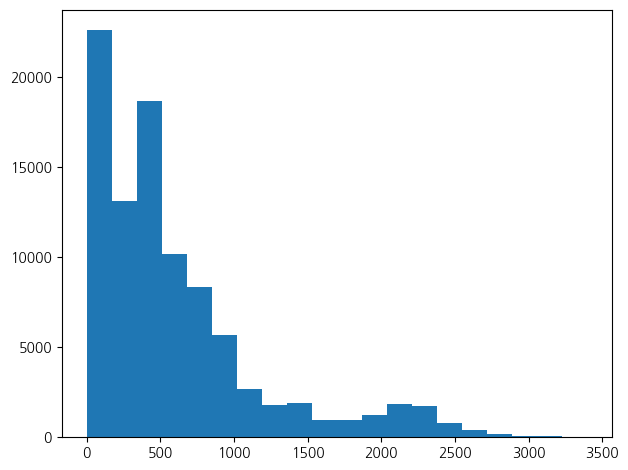

In [14]:
plt.hist(x=filtered_data['distance'], bins=20)
plt.tight_layout()
plt.show()

## 파생 변수 - 배송 시간

In [15]:
filtered_data['delivered_days'] = (filtered_data['delivered_time'] - filtered_data['purchase_time']).dt.days
filtered_data['approved_hours'] = (filtered_data['approved_time'] - filtered_data['purchase_time']).dt.components.hours
filtered_data['delayed_days'] = (filtered_data['delivered_time'] - filtered_data['estimated_delivery_time']).dt.days

filtered_data.head(10)

,latitude_cust,longitude_cust,seller_id,latitude_sell,longitude_sell,purchase_time,approved_time,delivered_time,estimated_delivery_time,state_cust,zip_code_cust,state_sell,is_repurchase,review_score,distance,delivered_days,approved_hours,delayed_days
0,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-11 13:14:05,2017-02-01,PR,80030,PR,0,5.0,10.337962,6,0,-21
1,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 12:01:20,2017-01-07 03:35:37,2017-01-17 15:38:58,2017-02-13,PR,80030,PR,0,5.0,10.337962,12,15,-27
2,-25.406155,-49.257755,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 12:06:36,2017-01-07 03:45:22,2017-01-16 16:05:22,2017-02-13,PR,80540,PR,0,5.0,11.083577,11,15,-28
3,-25.451968,-49.267206,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 12:14:58,2017-01-07 03:35:24,2017-01-16 16:13:55,2017-02-01,PR,80220,PR,0,5.0,6.053982,11,15,-16
4,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 13:01:48,2017-01-07 03:45:49,2017-01-16 15:43:21,2017-02-13,PR,80030,PR,0,5.0,10.337962,11,14,-28
5,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 13:29:03,2017-01-07 03:45:23,2017-01-16 16:05:21,2017-02-01,PR,80030,PR,0,5.0,10.337962,11,14,-16
6,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 13:31:22,2017-01-07 03:44:29,2017-01-16 16:05:21,2017-02-01,PR,80030,PR,0,5.0,10.337962,11,14,-16
7,-25.390224,-49.209119,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 13:33:45,2017-01-07 03:44:27,2017-01-17 16:51:39,2017-02-01,PR,82600,PR,0,5.0,14.998239,12,14,-15
8,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 13:34:35,2017-01-07 03:45:40,2017-01-17 15:52:28,2017-02-13,PR,80030,PR,0,5.0,10.337962,12,14,-27
9,-25.413097,-49.258480,48efc9d94a9834137efd9ea76b065a38,-25.49935,-49.296911,2017-01-05 13:36:41,2017-01-07 03:44:29,2017-01-16 15:53:34,2017-02-01,PR,80030,PR,0,5.0,10.337962,11,14,-16


## 파생변수 - 배송 효율

In [16]:
filtered_data['delivery_efficiency'] = np.log1p(filtered_data['delivered_days']) - np.log1p(filtered_data['distance'])

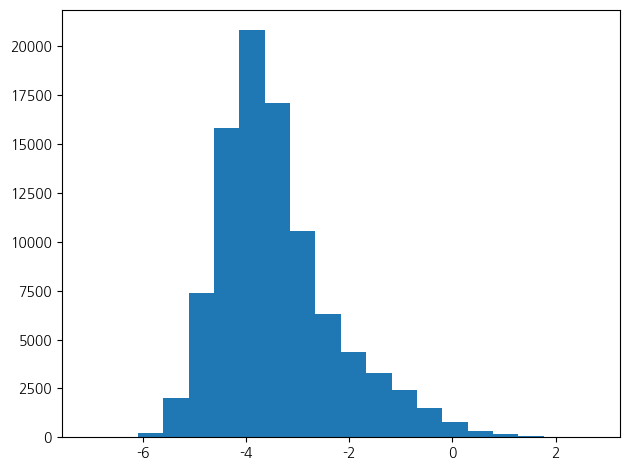

In [17]:
plt.hist(x=filtered_data['delivery_efficiency'], bins=20)
plt.tight_layout()
plt.show()

## 파생변수 - 리뷰

In [18]:
plus_review = filtered_data.copy()
plus_review['no_review'] = 1
plus_review.loc[plus_review['review_score'] == '리뷰없음', 'no_review'] = 0
plus_review.loc[plus_review['review_score'] == '리뷰없음', 'review_score'] = np.nan
plus_review['review_score'] = plus_review['review_score'].astype(float)
plus_review.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93182 entries, 0 to 93387
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   latitude_cust            93182 non-null  float64       
 1   longitude_cust           93182 non-null  float64       
 2   seller_id                93182 non-null  object        
 3   latitude_sell            93182 non-null  float64       
 4   longitude_sell           93182 non-null  float64       
 5   purchase_time            93182 non-null  datetime64[ns]
 6   approved_time            93182 non-null  datetime64[ns]
 7   delivered_time           93182 non-null  datetime64[ns]
 8   estimated_delivery_time  93182 non-null  datetime64[ns]
 9   state_cust               93182 non-null  object        
 10  zip_code_cust            93182 non-null  int64         
 11  state_sell               93182 non-null  object        
 12  is_repurchase            93182 non-nu

In [ ]:
# 파생변수 생성 끝난 데이터
data: pd.DataFrame = plus_review.copy()

## 기술 통계

In [20]:
data['distance'].describe()

count    93182.000000
mean       599.783663
std        591.293521
min          0.000000
25%        185.291349
50%        433.638314
75%        798.670928
max       3399.318090
Name: distance, dtype: float64

#### 거리 구간 설정

In [21]:
# 일반 분할

bins = [0, 100, 500, 1000, 2000, 4400]
labels = [
    '근거리 (0-100km)',
    '인근 (100-500km)',
    '중거리 (500-1,000km)',
    '장거리 (1,000-2,000km)',
    '초장거리 (2,000km+)'
]
data['distance_label'] = pd.cut(data['distance'], bins=bins, right=False, labels=labels)

In [39]:
group1 = data.groupby('distance_label', observed=True).agg(
    개수=('distance_label', 'size'),
    평균거리=('distance', 'mean'),
    평균배달소요일=('delivered_days', 'mean'),
    평균승인소요시간=('approved_hours', 'mean'),
    평균지연시간=('delayed_days', 'mean'),
    평균배달효율=('delivery_efficiency', 'mean'),
    평균평점=('review_score', 'mean'),
    리뷰=('no_review', 'sum'),
    재구매=('is_repurchase', 'sum')
)

group1['재구매율'] = (group1['재구매'] / group1['개수'] * 100).round(2)
group1['리뷰작성율'] = (group1['리뷰'] / group1['개수'] * 100).round(2)
group1

,개수,평균거리,평균배달소요일,평균승인소요시간,평균지연시간,평균배달효율,평균평점,리뷰,재구매,재구매율,리뷰작성율
distance_label,,,,,,,,,,,
근거리 (0-100km),17367,40.069448,6.009328,3.431738,-9.506535,-1.657037,4.252868,17258,520,2.99,99.37
인근 (100-500km),35937,322.542558,10.958205,3.473662,-12.084342,-3.382184,4.159554,35712,1002,2.79,99.37
"중거리 (500-1,000km)",25019,712.382652,13.760542,3.668692,-12.682521,-3.989625,4.087056,24846,675,2.70,99.31
"장거리 (1,000-2,000km)",9444,1402.271529,17.454257,3.791720,-12.858005,-4.432500,4.034023,9376,258,2.73,99.28
"초장거리 (2,000km+)",5415,2315.011881,20.707110,4.094552,-12.563804,-4.789524,3.959933,5366,142,2.62,99.10


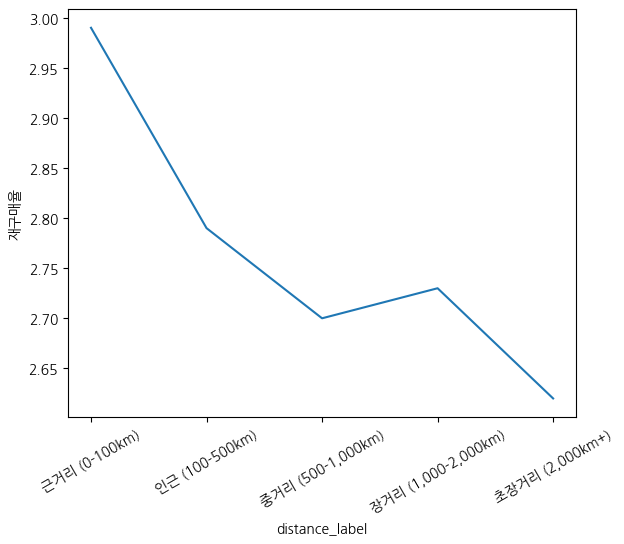

In [42]:
sns.lineplot(group1['재구매율'])
plt.tight_layout()
plt.xticks(rotation=30)
plt.show()

In [45]:
# 분위수 기반 분할

def cut_groupq(data: pd.DataFrame, qnum=4):
    labels = [f'Q{i+1}' for i in range(qnum)]
    data['distance_quartile'] = pd.qcut(data['distance'], qnum, labels=labels)
    

def gen_groupq(data: pd.DataFrame):
    group2 = data.groupby('distance_quartile', observed=True).agg(
        개수=('distance_quartile', 'size'),
        평균거리=('distance', 'mean'),
        평균배달소요일=('delivered_days', 'mean'),
        평균승인소요시간=('approved_hours', 'mean'),
        평균지연시간=('delayed_days', 'mean'),
        평균배달효율=('delivery_efficiency', 'mean'),
        평균평점=('review_score', 'mean'),
        리뷰=('no_review', 'sum'),
        재구매=('is_repurchase', 'sum')
    )

    group2['재구매율'] = (group2['재구매'] / group2['개수'] * 100).round(2)
    group2['리뷰작성율'] = (group2['리뷰'] / group2['개수'] * 100).round(2)
    return group2
    

,개수,평균거리,평균배달소요일,평균승인소요시간,평균지연시간,평균배달효율,평균평점,리뷰,재구매,재구매율,리뷰작성율
distance_quartile,,,,,,,,,,,
Q1,23296,65.027888,6.539964,3.481284,-9.928529,-1.969775,4.265097,23150,662,2.84,99.37
Q2,23295,327.162500,11.391200,3.402018,-12.209959,-3.406429,4.133135,23142,683,2.93,99.34
Q3,23295,582.778043,13.120670,3.639021,-12.361408,-3.844768,4.090905,23134,625,2.68,99.31
Q4,23296,1424.153787,17.000859,3.823789,-12.983259,-4.426984,4.043576,23132,627,2.69,99.30


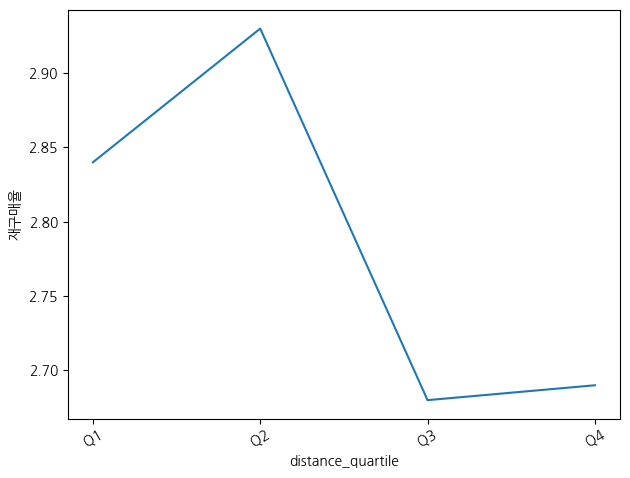

,개수,평균거리,평균배달소요일,평균승인소요시간,평균지연시간,평균배달효율,평균평점,리뷰,재구매,재구매율,리뷰작성율
distance_quartile,,,,,,,,,,,
Q1,18637,44.660914,6.123518,3.455223,-9.564630,-1.728612,4.256831,18518,541,2.90,99.36
Q2,18636,253.168998,10.388012,3.449775,-11.889032,-3.216075,4.166586,18519,552,2.96,99.37
Q3,18636,433.252547,11.940009,3.502254,-12.427238,-3.652735,4.132203,18517,494,2.65,99.36
Q4,18636,697.180726,13.791157,3.675520,-12.567182,-3.972862,4.080884,18508,508,2.73,99.31
Q5,18637,1570.632821,17.823148,3.849869,-12.905886,-4.489670,4.029358,18496,502,2.69,99.24


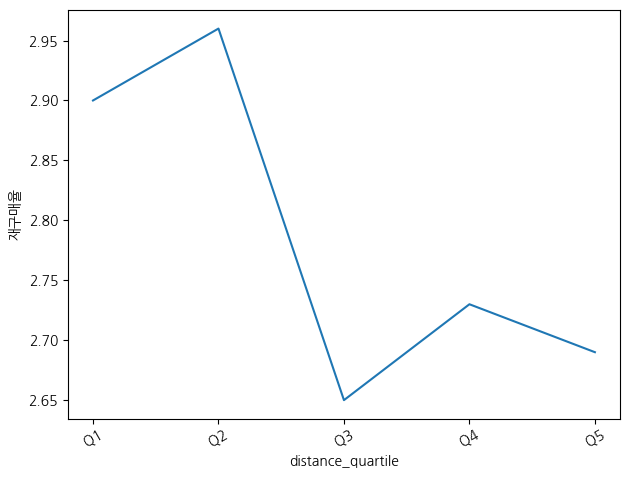

,개수,평균거리,평균배달소요일,평균승인소요시간,평균지연시간,평균배달효율,평균평점,리뷰,재구매,재구매율,리뷰작성율
distance_quartile,,,,,,,,,,,
Q1,15531,33.903539,5.890026,3.445045,-9.523598,-1.537869,4.255412,15430,456,2.94,99.35
Q2,15530,192.060127,9.217643,3.513715,-11.281069,-3.031876,4.222114,15438,449,2.89,99.41
Q3,15530,362.323919,11.789118,3.366194,-12.403091,-3.494588,4.119813,15424,440,2.83,99.32
Q4,15530,518.039417,12.540760,3.566130,-12.382228,-3.783755,4.091804,15435,410,2.64,99.39
Q5,15530,790.133171,14.167547,3.724082,-12.818158,-4.075196,4.093827,15422,420,2.70,99.30
Q6,15531,1702.207253,18.473891,3.903998,-12.816625,-4.548670,4.016030,15409,422,2.72,99.21


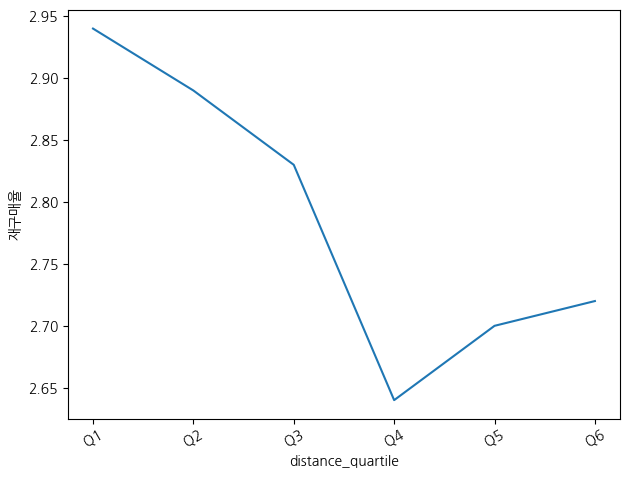

,개수,평균거리,평균배달소요일,평균승인소요시간,평균지연시간,평균배달효율,평균평점,리뷰,재구매,재구매율,리뷰작성율
distance_quartile,,,,,,,,,,,
Q1,13312,26.854121,5.753906,3.439078,-9.475962,-1.378638,4.261402,13221,400,3.00,99.32
Q2,13312,142.055403,8.264648,3.513897,-10.905574,-2.846268,4.252946,13240,382,2.87,99.46
Q3,13311,319.047516,11.446323,3.348359,-12.163023,-3.396145,4.103177,13220,372,2.79,99.32
Q4,13312,432.936017,11.909029,3.538462,-12.425706,-3.655121,4.141551,13232,368,2.76,99.40
Q5,13311,595.326993,13.432349,3.596649,-12.242732,-3.852767,4.073732,13210,356,2.67,99.24
Q6,13312,867.703011,14.306490,3.752178,-13.248122,-4.157883,4.096757,13229,358,2.69,99.38
Q7,13312,1814.541153,18.979492,3.917067,-12.634390,-4.597100,4.002499,13206,361,2.71,99.20


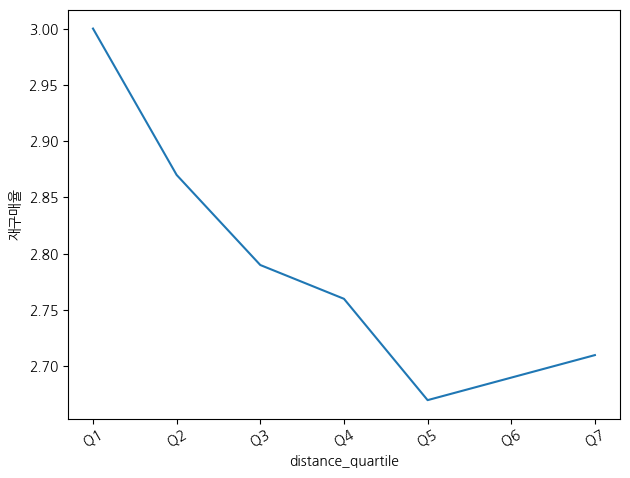

,개수,평균거리,평균배달소요일,평균승인소요시간,평균지연시간,평균배달효율,평균평점,리뷰,재구매,재구매율,리뷰작성율
distance_quartile,,,,,,,,,,,
Q1,11648,22.304043,5.653932,3.423592,-9.435096,-1.252306,4.262771,11569,341,2.93,99.32
Q2,11648,107.751732,7.425996,3.538977,-10.421961,-2.687243,4.267421,11581,321,2.76,99.42
Q3,11647,278.076079,10.999571,3.411093,-11.927535,-3.280724,4.118369,11574,357,3.07,99.37
Q4,11648,376.244707,11.782795,3.392943,-12.492359,-3.532123,4.147908,11568,326,2.80,99.31
Q5,11648,494.246214,12.151271,3.623197,-12.497253,-3.769963,4.118110,11574,304,2.61,99.36
Q6,11647,671.317474,14.090152,3.654847,-12.225552,-3.919579,4.063668,11560,321,2.76,99.25
Q7,11648,938.526251,14.631353,3.696858,-13.391827,-4.218261,4.092754,11579,308,2.64,99.41
Q8,11648,1909.781323,19.370364,3.950721,-12.574691,-4.635708,3.994287,11553,319,2.74,99.18


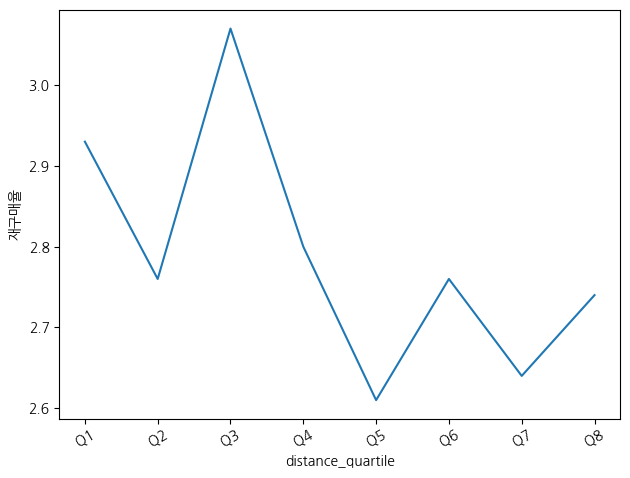

In [46]:
for i in range(4, 9):
    cut_groupq(data, i)
    group2 = gen_groupq(data)
    display(group2)
    sns.lineplot(group2['재구매율'])
    plt.tight_layout()
    plt.xticks(rotation=30)
    plt.show()
    

In [48]:
cut_groupq(data, 7)

## 시각화 함수

In [ ]:
# 박스플롯 시각화 함수
def plot_box(axes: Axes, x: ArrayLike | Sequence[ArrayLike], ylabel, label:Sequence[str] = None, color: str | Sequence[str] = 'skyblue', target_value=None, target_label='기준값'):
    bp = axes.boxplot(x=x, label=label, patch_artist=True)
    color = [color] if isinstance(color, str) else color
    for i in range(len(color)):
        bp['boxes'][i].set_facecolor(color[i])
    if target_value:
        axes.axhline(target_value, color='red', linestyle='--', linewidth=2)
        axes.text(1.1, target_value, f'{target_label}: {target_value}')
    axes.set_ylabel(ylabel)
    axes.set_title(f'{ylabel} 분포 박스플롯')
    axes.grid(True, alpha=0.3)

In [ ]:
def plot_hist(axes: Axes, x: pd.Series, xlabel: str, alpha: float, bins: int, density=False, color: str | Sequence[str] = 'skyblue', target_value=None, target_label='기준값'):
    axes.hist(x, bins=bins, edgecolor='black', alpha=alpha, color=color, density=density)
    if target_value:
        axes.axvline(target_value, color='red', linestyle='--', linewidth=2, label=target_label)
        axes.axvline(x.mean(), color='blue', linestyle='--', linewidth=2, label=f'평균: {x.mean():.1f}')
    
    axes.set_xlabel(f'{xlabel}')
    axes.set_ylabel('빈도')
    axes.set_title(f'{xlabel} 분포')
    axes.legend()
    axes.grid(True, alpha=0.3)

## 통계 분석



### 배송과 재구매의 독립성 - 카이제곱

In [54]:
group = pd.DataFrame()

print("\n[분할표 (Contingency Table)]")
group['재구매 O'] = group1['재구매'] 
group['재구매 X'] = group1['개수'] - group1['재구매']
group


[분할표 (Contingency Table)]


,재구매 O,재구매 X
distance_label,,
근거리 (0-100km),520,16847
인근 (100-500km),1002,34935
"중거리 (500-1,000km)",675,24344
"장거리 (1,000-2,000km)",258,9186
"초장거리 (2,000km+)",142,5273


/tmp/ipykernel_160976/2133523279.py:15: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  data.T.plot(kind='bar', stacked=True, ax=axes, colormap=cmap, color=colors)


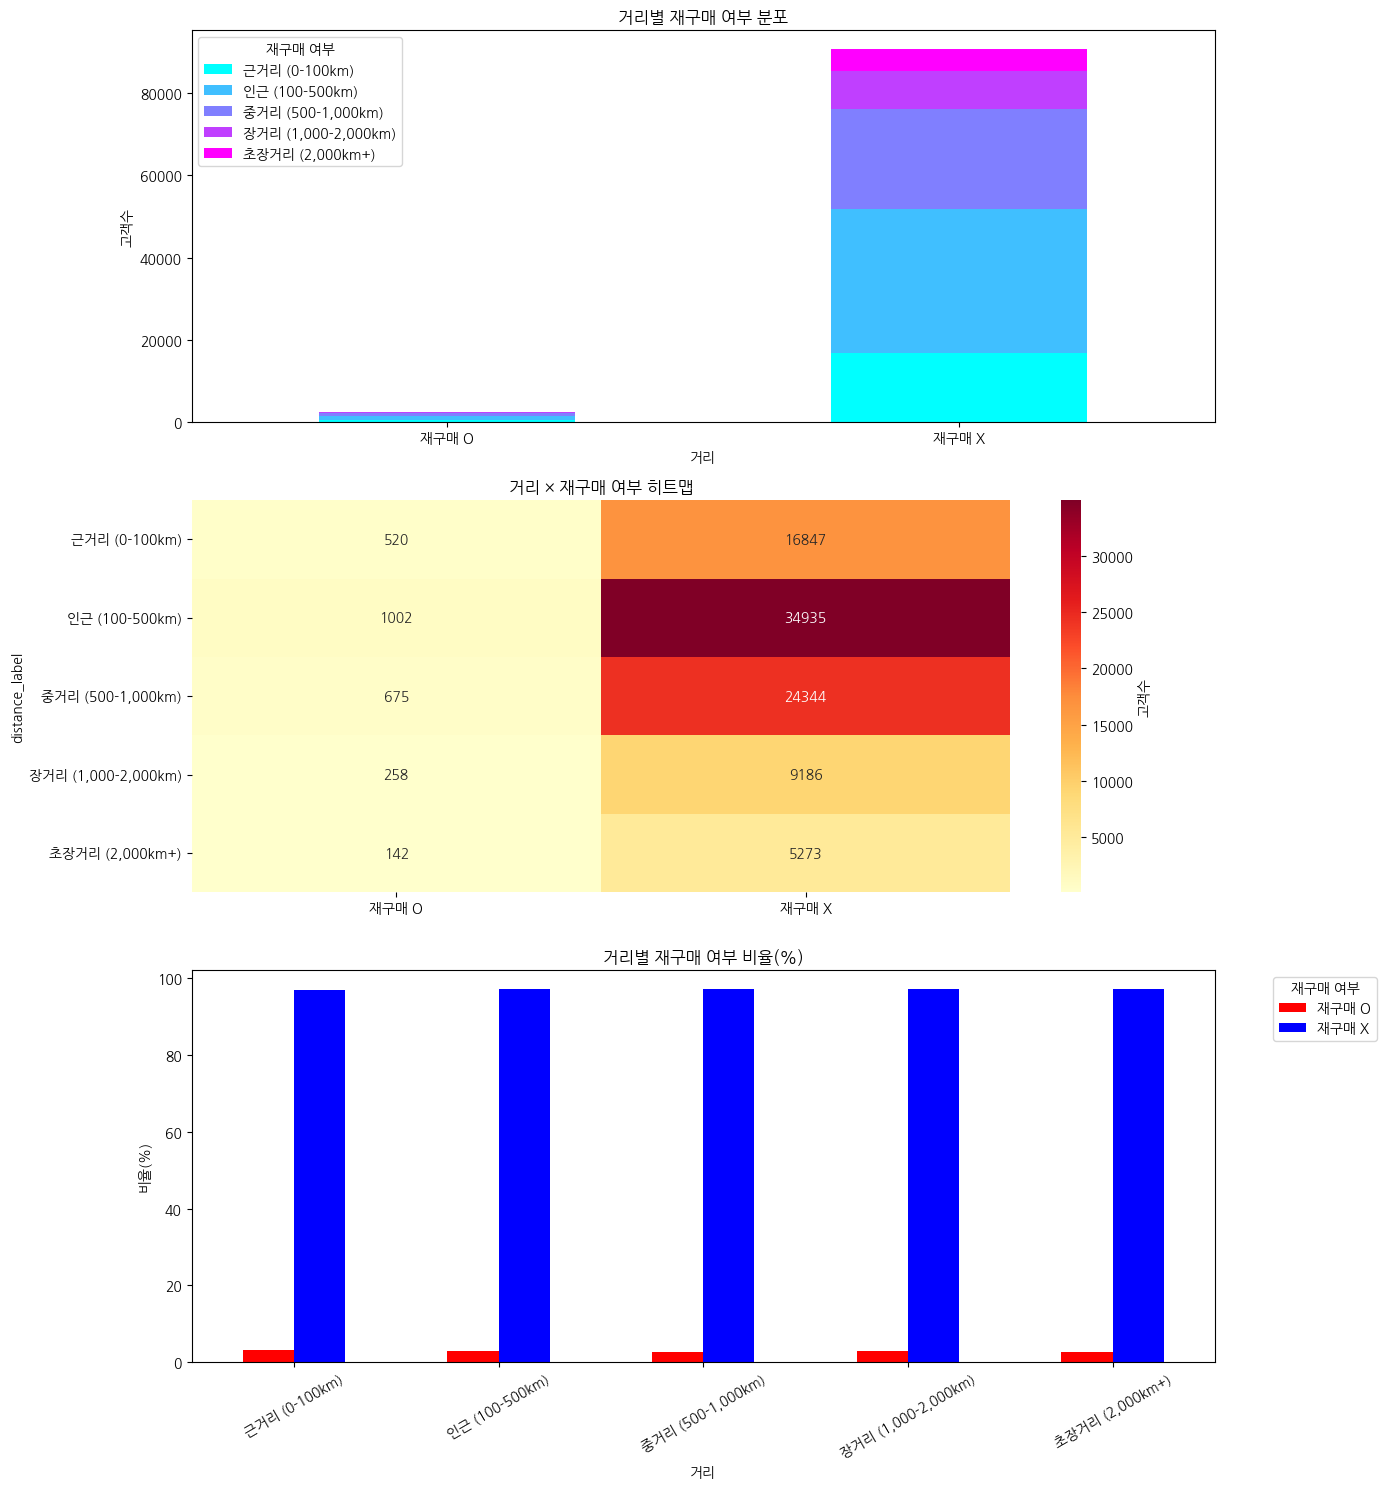

In [73]:
# 색상 목록 정의 (RGB 튜플 또는 16진수 코드 사용)
distance_colormap = 'cool'

repurchase_colors = ['red','blue']

var1 = '거리'
var2 = '재구매 여부'
label = '고객수'

# TODO: 1. 데이터 시각화
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# 누적 막대그래프
def plot_stacked_bar(data: pd.DataFrame, axes: Axes, var1: str, var2: str, label: str, colors: dict = None, cmap: str | Colormap | None = None):
    data.T.plot(kind='bar', stacked=True, ax=axes, colormap=cmap, color=colors)
    axes.set_title(f'{var1}별 {var2} 분포')
    axes.set_xlabel(var1)
    axes.set_ylabel(label)
    axes.legend(title=var2)
    axes.set_xticklabels(axes.get_xticklabels(), rotation=0)

plot_stacked_bar(group, axes[0], var1, var2, label, cmap=distance_colormap)

# 히트맵
def plot_heatmap(data: pd.DataFrame, axes: Axes, var1: str, var2: str, label: str, cmap: str | Colormap | None = 'YlOrRd'):
    sns.heatmap(data, annot=True, fmt='d', cmap=cmap, ax=axes, cbar_kws={'label': label})
    axes.set_title(f'{var1} × {var2} 히트맵')

plot_heatmap(group, axes[1], var1, var2, label)


# 비율 막대그래프
def plot_prop_bar(data: pd.DataFrame, axes: Axes, var1: str, var2: str, colors: Any = None, cmap: str | Colormap | None = None, rotation=None):
    prop_table = data.div(data.sum(axis=1), axis=0) * 100
    prop_table.plot(kind='bar', ax=axes, color=colors)
    axes.set_title(f'{var1}별 {var2} 비율(%)')
    axes.set_ylabel('비율(%)')
    axes.set_xlabel(var1)
    axes.set_xticklabels(axes.get_xticklabels(), rotation=0)
    axes.legend(title=f'{var2}', bbox_to_anchor=(1.05, 1))
    axes.tick_params(axis='x', labelrotation=rotation)
    

plot_prop_bar(group, axes[2], var1, var2, repurchase_colors, rotation=30)
plt.tight_layout()
plt.show()

### 배송 거리와 평점

In [ ]:
data['review_score'].value_counts()

In [ ]:
grouped2 = data.groupby(['distance_label', 'review_score'], observed=True).size()
grouped2

In [ ]:
grouped2.unstack()